In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import numpy as np


csv_path = "radiomics_comparison.csv"

df = pd.read_csv(csv_path)


In [2]:
list(df.columns)

['patient_id',
 'organ_gt',
 'organ_generated',
 'tumor_mean_abs_error',
 'tumor_mean_percent_error',
 'tumor_gt_attenuation_delta',
 'tumor_gt_original_firstorder_10Percentile',
 'tumor_gt_original_firstorder_90Percentile',
 'tumor_gt_original_firstorder_Energy',
 'tumor_gt_original_firstorder_Entropy',
 'tumor_gt_original_firstorder_InterquartileRange',
 'tumor_gt_original_firstorder_Kurtosis',
 'tumor_gt_original_firstorder_Maximum',
 'tumor_gt_original_firstorder_Mean',
 'tumor_gt_original_firstorder_MeanAbsoluteDeviation',
 'tumor_gt_original_firstorder_Median',
 'tumor_gt_original_firstorder_Minimum',
 'tumor_gt_original_firstorder_Range',
 'tumor_gt_original_firstorder_RobustMeanAbsoluteDeviation',
 'tumor_gt_original_firstorder_RootMeanSquared',
 'tumor_gt_original_firstorder_Skewness',
 'tumor_gt_original_firstorder_TotalEnergy',
 'tumor_gt_original_firstorder_Uniformity',
 'tumor_gt_original_firstorder_Variance',
 'tumor_gt_original_glcm_Autocorrelation',
 'tumor_gt_original_

In [3]:
df.columns

Index(['patient_id', 'organ_gt', 'organ_generated', 'tumor_mean_abs_error',
       'tumor_mean_percent_error', 'tumor_gt_attenuation_delta',
       'tumor_gt_original_firstorder_10Percentile',
       'tumor_gt_original_firstorder_90Percentile',
       'tumor_gt_original_firstorder_Energy',
       'tumor_gt_original_firstorder_Entropy',
       ...
       'mask_abs_error_original_shape_Maximum2DDiameterColumn',
       'mask_abs_error_original_shape_Maximum2DDiameterRow',
       'mask_abs_error_original_shape_Maximum2DDiameterSlice',
       'mask_abs_error_original_shape_Maximum3DDiameter',
       'mask_abs_error_original_shape_MeshVolume',
       'mask_abs_error_original_shape_MinorAxisLength',
       'mask_abs_error_original_shape_Sphericity',
       'mask_abs_error_original_shape_SurfaceArea',
       'mask_abs_error_original_shape_SurfaceVolumeRatio',
       'mask_abs_error_original_shape_VoxelVolume'],
      dtype='object', length=332)

Found 107 matching features


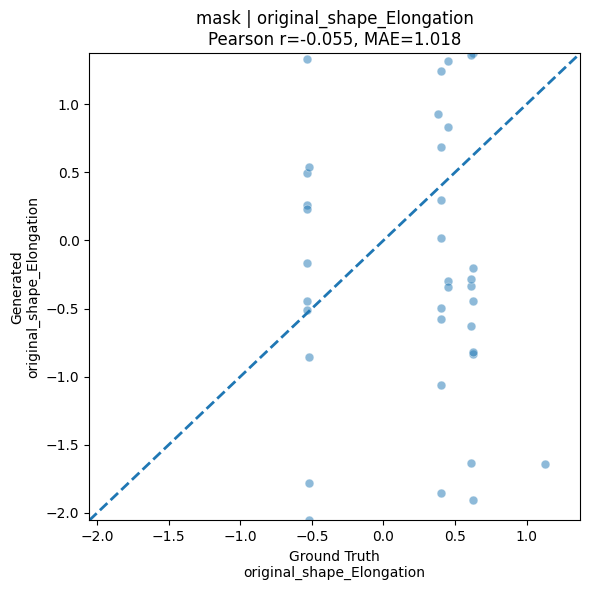

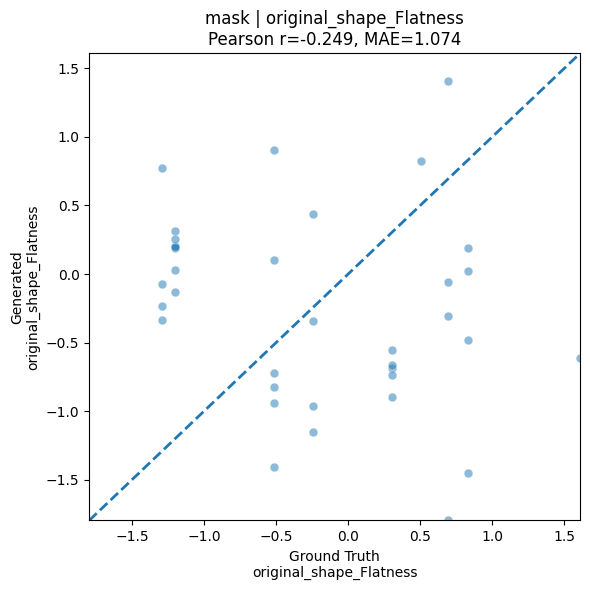

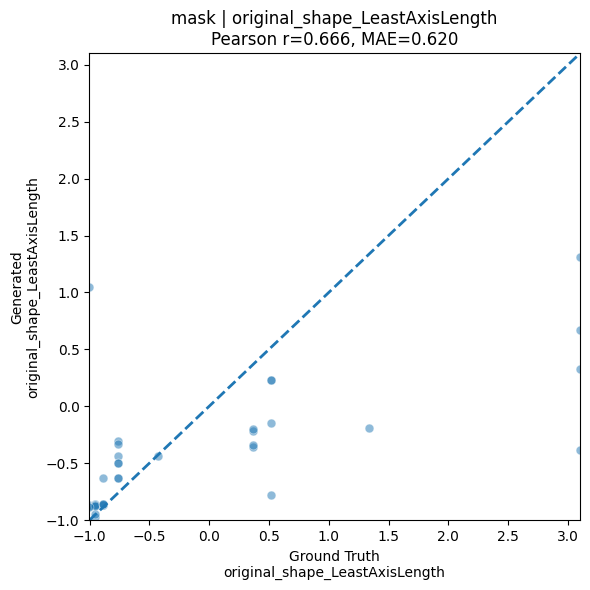

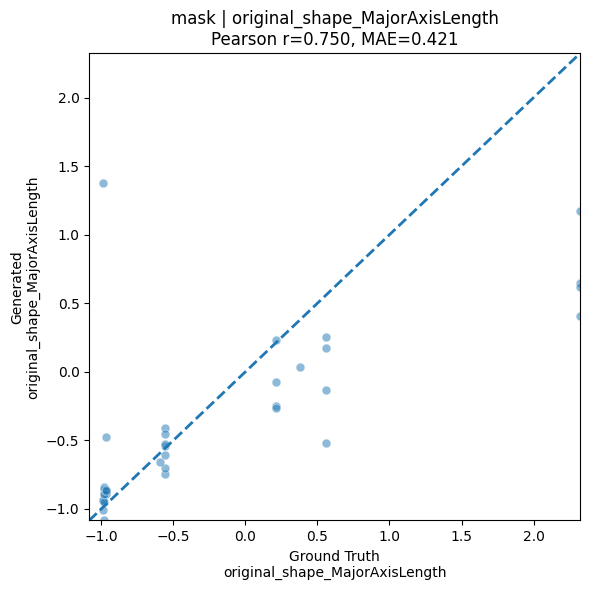

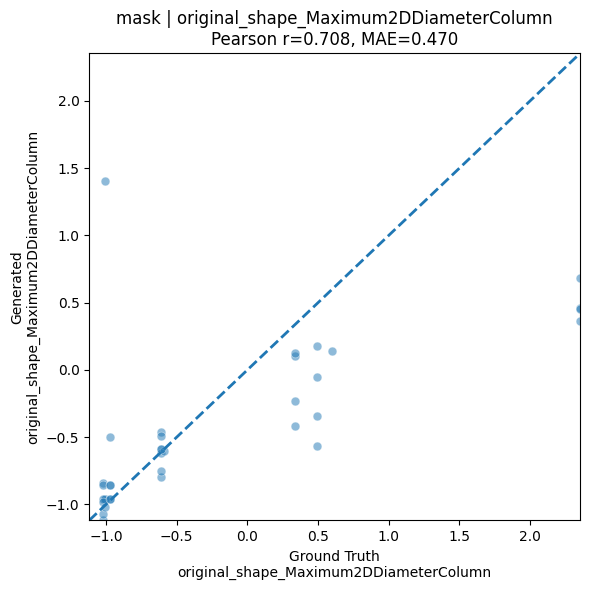

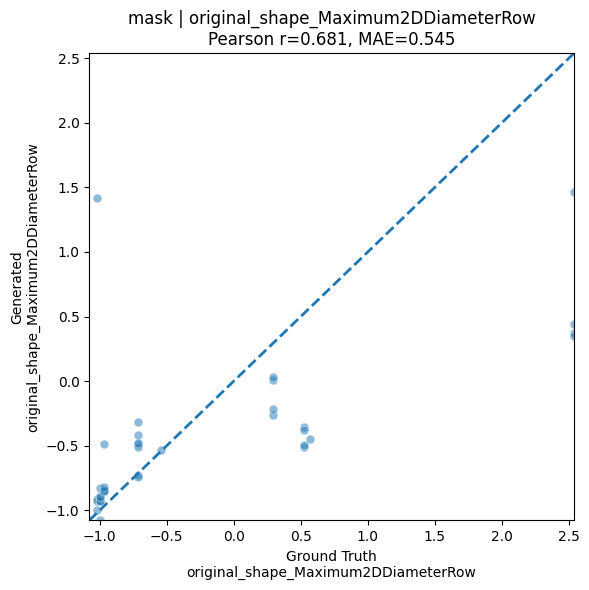

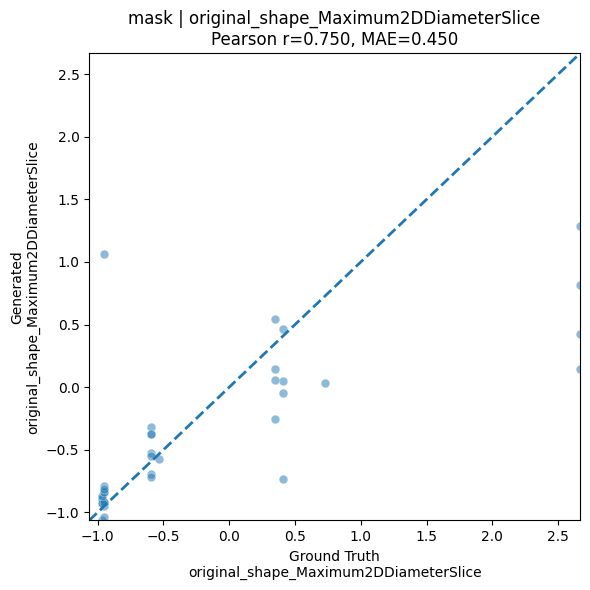

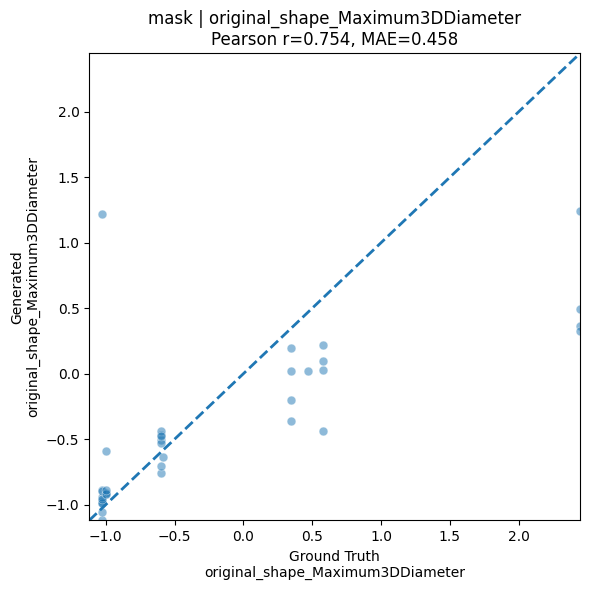

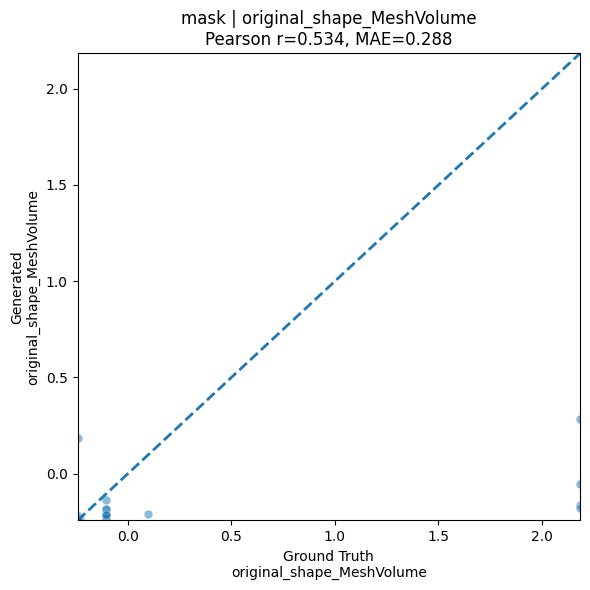

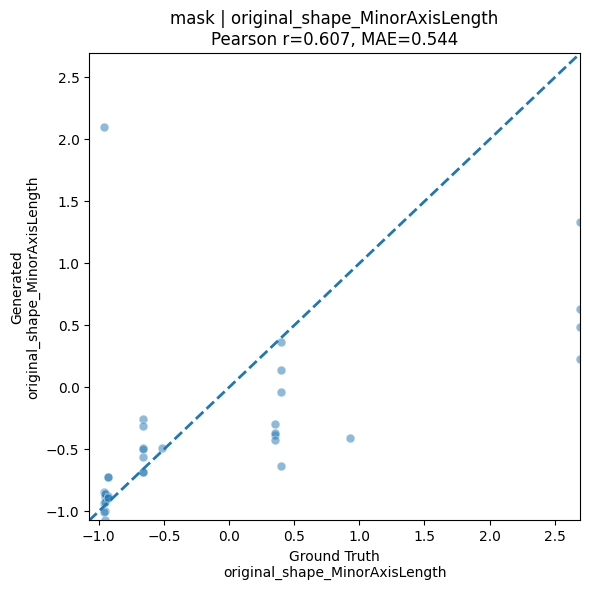

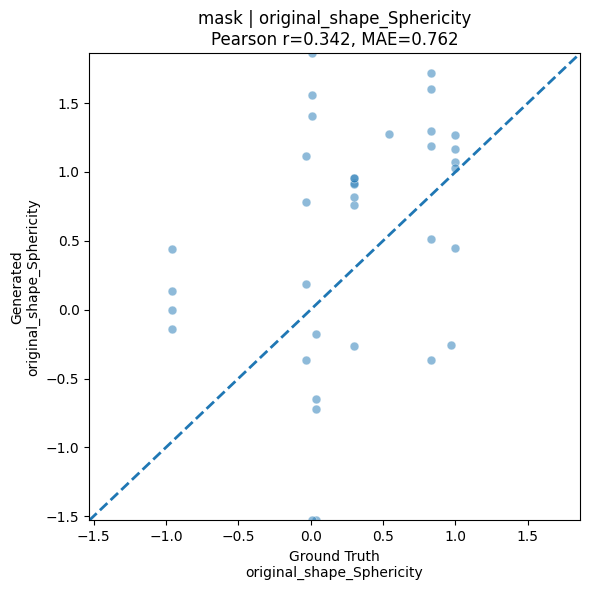

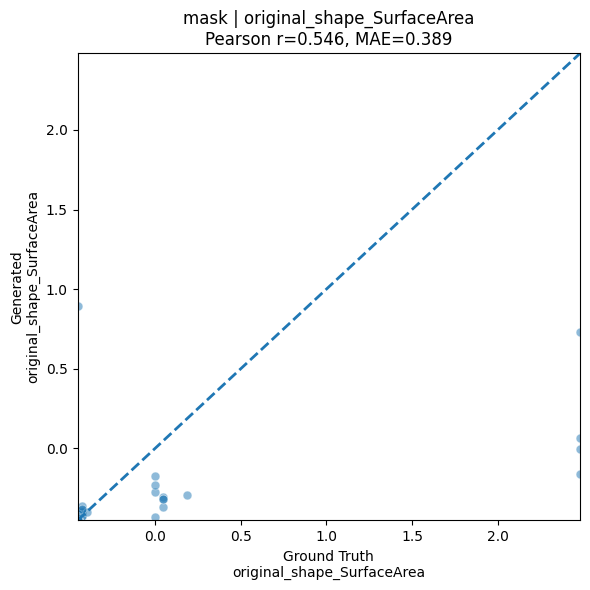

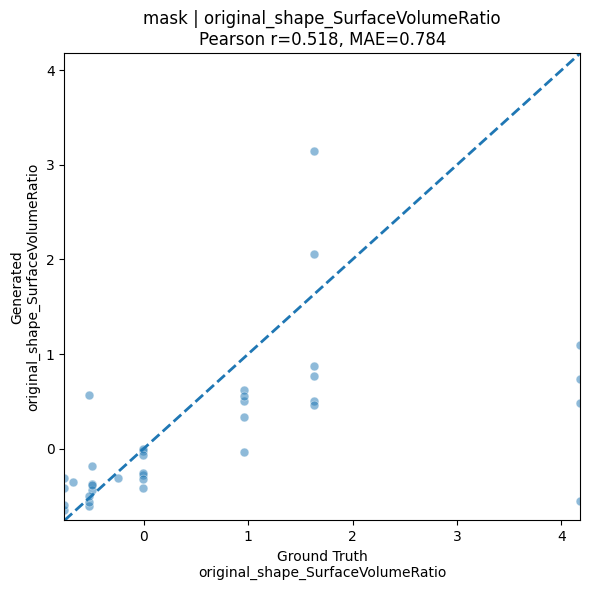

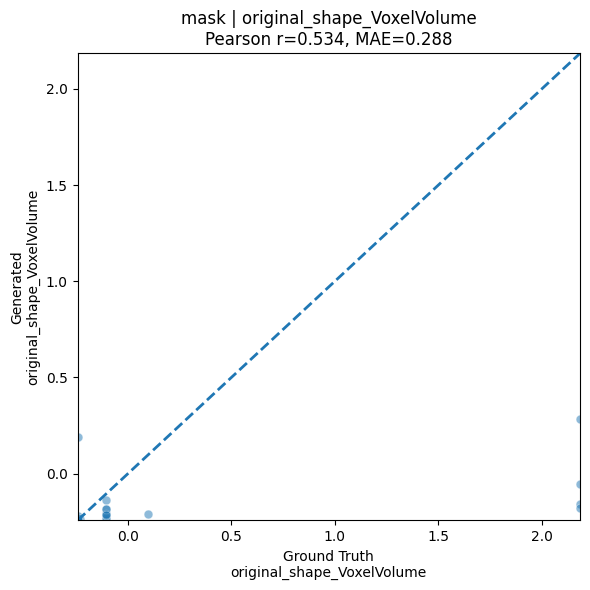

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


# Find matching gt/gen feature pairs across both feature groups
# (mask_gt_* / mask_gen_* and tumor_gt_* / tumor_gen_*)
features = []

for prefix in ("mask_", "tumor_"):

    gt_prefix = f"{prefix}gt_"
    gen_prefix = f"{prefix}gen_"

    for c in df.columns:

        if not c.startswith(gt_prefix):
            continue

        feature = c[len(gt_prefix):]
        gen_col = f"{gen_prefix}{feature}"

        if gen_col in df.columns:
            features.append((prefix, feature))


print(f"Found {len(features)} matching features")


for prefix, feature in features:

    if "shape" not in feature:
        continue

    gt_col = f"{prefix}gt_{feature}"
    gen_col = f"{prefix}gen_{feature}"

    plot_df = df[[gt_col, gen_col]].dropna()

    if len(plot_df) < 3:
        continue

    x = plot_df[gt_col]
    y = plot_df[gen_col]

    # Statistics
    r, _ = pearsonr(x, y)
    mae = np.mean(np.abs(x - y))


    plt.figure(figsize=(6, 6))

    sns.scatterplot(
        data=plot_df,
        x=gt_col,
        y=gen_col,
        alpha=0.5,
        s=40
    )


    # y=x identity line
    lims = [
        min(x.min(), y.min()),
        max(x.max(), y.max())
    ]

    plt.plot(
        lims,
        lims,
        "--",
        linewidth=2
    )

    plt.xlim(lims)
    plt.ylim(lims)


    plt.xlabel(f"Ground Truth\n{feature}")
    plt.ylabel(f"Generated\n{feature}")

    plt.title(
        f"{prefix.rstrip('_')} | {feature}\n"
        f"Pearson r={r:.3f}, MAE={mae:.3f}"
    )

    plt.tight_layout()

    # Display instead of saving
    plt.show()

In [23]:
features

[('mask_', 'original_shape_Elongation'),
 ('mask_', 'original_shape_Flatness'),
 ('mask_', 'original_shape_LeastAxisLength'),
 ('mask_', 'original_shape_MajorAxisLength'),
 ('mask_', 'original_shape_Maximum2DDiameterColumn'),
 ('mask_', 'original_shape_Maximum2DDiameterRow'),
 ('mask_', 'original_shape_Maximum2DDiameterSlice'),
 ('mask_', 'original_shape_Maximum3DDiameter'),
 ('mask_', 'original_shape_MeshVolume'),
 ('mask_', 'original_shape_MinorAxisLength'),
 ('mask_', 'original_shape_Sphericity'),
 ('mask_', 'original_shape_SurfaceArea'),
 ('mask_', 'original_shape_SurfaceVolumeRatio'),
 ('mask_', 'original_shape_VoxelVolume'),
 ('tumor_', 'original_firstorder_10Percentile'),
 ('tumor_', 'original_firstorder_90Percentile'),
 ('tumor_', 'original_firstorder_Energy'),
 ('tumor_', 'original_firstorder_Entropy'),
 ('tumor_', 'original_firstorder_InterquartileRange'),
 ('tumor_', 'original_firstorder_Kurtosis'),
 ('tumor_', 'original_firstorder_Maximum'),
 ('tumor_', 'original_firstorder